## **Analisis Saham IHSG BEI**

In [ ]:
!pip install factor_analyzer

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mstats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

ihsg = pd.read_csv('/content/Data Saham IHSG.csv')
print(f"Shape awal: {ihsg.shape}")
ihsg.head()

Shape awal: (960, 16)


,Symbol,Market Cap,Current PE Ratio (TTM),EV to EBITDA (TTM),Current Price to Book Value,Dividend Yield,Dividend Payout Ratio FY,Gross Profit Margin (TTM)(%),Net Profit Margin (TTM)(%),Return on Assets (TTM),Return on Equity (TTM),Asset Turnover (TTM),Inventory Turnover (TTM),Current Ratio (Quarter),Quick Ratio (Quarter),Debt to Equity Ratio (Quarter)
0,SBAT,4.75 B,-0.07,-9.08,0.03,-,-,0.1589,-2.0807,-0.1136,-0.4952,0.05,0.14,0.51,0.07,2.29
1,MKNT,5.50 B,-,153.28,-0.61,-,-,-,-,-,-,-,-,-,-,-
2,DEAL,6.88 B,-0.38,-33.82,-0.12,-,-,0.0585,-0.3097,-0.1191,0.3155,0.38,13.14,0.6,0.56,-2.63
3,KAYU,8.58 B,10.64,-12.01,0.11,-,-,0.0157,0.1198,0.0082,0.0099,0.07,0.19,5.58,3.49,0.1
4,TOYS,11.48 B,-0.84,-72.27,0.05,-,-,0.1153,-0.2254,-0.0382,-0.055,0.17,0.52,3.24,2.16,0.35


## **Deduplikasi**

In [ ]:
print("Duplikat ditemukan:", ihsg.duplicated().sum())
print("Duplikat berdasarkan Symbol:", ihsg.duplicated(subset=['Symbol']).sum())

Duplikat ditemukan: 25
Duplikat berdasarkan Symbol: 25


In [ ]:
duplikat = ihsg[ihsg.duplicated(subset=['Symbol'], keep=False)]
print(duplikat[['Symbol']].sort_values('Symbol'))

    Symbol
20    AEGS
939   AEGS
937   ALTO
22    ALTO
954   ARTI
5     ARTI
942   BIKA
17    BIKA
10    BMBL
949   BMBL
946   CNTX
13    CNTX
2     DEAL
957   DEAL
947   FIMP
12    FIMP
14    HADE
945   HADE
950   INDX
9     INDX
956   KAYU
3     KAYU
935   KICI
24    KICI
21    LMAS
938   LMAS
8     LMSH
951   LMSH
958   MKNT
1     MKNT
948   PLAN
11    PLAN
23    RICY
936   RICY
0     SBAT
959   SBAT
953   SIMA
6     SIMA
15    SKYB
944   SKYB
940   SOUL
19    SOUL
941   TOPS
18    TOPS
955   TOYS
4     TOYS
952   UNIT
7     UNIT
943   WIDI
16    WIDI


In [ ]:
# Lihat detail baris duplikat untuk cek apakah data sama atau berbeda
duplikat_detail = ihsg[ihsg['Symbol'].isin([
    'AEGS','ALTO','ARTI','BIKA','BMBL','CNTX','DEAL','FIMP',
    'HADE','INDX','KAYU','KICI','LMAS','LMSH','MKNT','PLAN',
    'RICY','SBAT','SIMA','SKYB','SOUL','TOPS','TOYS','UNIT','WIDI'
])].sort_values('Symbol')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(duplikat_detail.to_string())

    Symbol Market Cap Current PE Ratio (TTM) EV to EBITDA (TTM) Current Price to Book Value Dividend Yield Dividend Payout Ratio FY Gross Profit Margin (TTM)(%) Net Profit Margin (TTM)(%) Return on Assets (TTM) Return on Equity (TTM) Asset Turnover (TTM) Inventory Turnover (TTM) Current Ratio (Quarter) Quick Ratio (Quarter) Debt to Equity Ratio (Quarter)
20    AEGS    37.22 B                      -                  -                        0.54              -                        -                            -                          -                      -                      -                    -                        -                    8.66                  4.93                              -
939   AEGS    37.22 B                      -                  -                        0.54              -                        -                            -                          -                      -                      -                    -                        -       

In [ ]:
ihsg = ihsg.drop_duplicates(keep='first')
ihsg = ihsg.reset_index(drop=True)
print(f"Shape setelah deduplikasi: {ihsg.shape}")

Shape setelah deduplikasi: (935, 16)


In [ ]:
ihsg.isnull().sum()

,0
Symbol,0
Market Cap,0
Current PE Ratio (TTM),0
EV to EBITDA (TTM),0
Current Price to Book Value,0
Dividend Yield,0
Dividend Payout Ratio FY,0
Gross Profit Margin (TTM)(%),0
Net Profit Margin (TTM)(%),0
Return on Assets (TTM),0


## **Cleaning Tipe Data**

In [ ]:
ihsg.replace('-', np.nan, inplace=True)

In [ ]:
if ihsg['Market Cap'].dtype == 'object':
    ihsg['Market Cap'] = (
        ihsg['Market Cap']
        .str.replace(' B', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
    )


In [ ]:
kolom_rasio = [
    'Current PE Ratio (TTM)', 'EV to EBITDA (TTM)', 'Current Price to Book Value',
    'Dividend Yield', 'Dividend Payout Ratio FY', 'Gross Profit Margin (TTM)(%)',
    'Net Profit Margin (TTM)(%)', 'Return on Assets (TTM)', 'Return on Equity (TTM)',
    'Asset Turnover (TTM)', 'Inventory Turnover (TTM)', 'Current Ratio (Quarter)',
    'Quick Ratio (Quarter)', 'Debt to Equity Ratio (Quarter)'
]

for col in kolom_rasio:
    if col in ihsg.columns and ihsg[col].dtype == 'object':
        ihsg[col] = ihsg[col].str.replace('%', '', regex=False).astype(float)

ihsg.dtypes

,0
Symbol,object
Market Cap,float64
Current PE Ratio (TTM),float64
EV to EBITDA (TTM),float64
Current Price to Book Value,float64
Dividend Yield,float64
Dividend Payout Ratio FY,float64
Gross Profit Margin (TTM)(%),float64
Net Profit Margin (TTM)(%),float64
Return on Assets (TTM),float64


## **Penanganan Missing Values**

In [ ]:
missing = ihsg.isnull().sum()
missing_pct = (missing / len(ihsg) * 100).round(2)

summary = pd.DataFrame({
    'Valid': ihsg.notnull().sum(),
    'Missing': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(summary[summary['Missing'] > 0])

                                Valid  Missing  Missing %
Dividend Yield                    375      560      59.89
Dividend Payout Ratio FY          569      366      39.14
Inventory Turnover (TTM)          703      232      24.81
Debt to Equity Ratio (Quarter)    710      225      24.06
Gross Profit Margin (TTM)(%)      832      103      11.02
Current Ratio (Quarter)           838       97      10.37
Quick Ratio (Quarter)             839       96      10.27
Asset Turnover (TTM)              875       60       6.42
Net Profit Margin (TTM)(%)        884       51       5.45
EV to EBITDA (TTM)                887       48       5.13
Current PE Ratio (TTM)            889       46       4.92
Return on Assets (TTM)            890       45       4.81
Return on Equity (TTM)            891       44       4.71
Current Price to Book Value       932        3       0.32


In [ ]:
ihsg = ihsg.drop(columns=['Dividend Yield', 'Dividend Payout Ratio FY'], errors='ignore')

In [ ]:
ihsg['Has_Inventory'] = ihsg['Inventory Turnover (TTM)'].notna().astype(int)
ihsg['Inventory Turnover (TTM)'] = ihsg['Inventory Turnover (TTM)'].fillna(0)

In [ ]:
kolom_imputasi = [
    'Current PE Ratio (TTM)', 'EV to EBITDA (TTM)', 'Current Price to Book Value',
    'Gross Profit Margin (TTM)(%)', 'Net Profit Margin (TTM)(%)',
    'Return on Assets (TTM)', 'Return on Equity (TTM)',
    'Asset Turnover (TTM)', 'Current Ratio (Quarter)', 'Quick Ratio (Quarter)',
    'Debt to Equity Ratio (Quarter)'
]

In [ ]:
zombie_mask = ihsg['Net Profit Margin (TTM)(%)'].isna() & ihsg['Return on Equity (TTM)'].isna()
print(f"Saham zombie di-drop: {zombie_mask.sum()}")
ihsg = ihsg[~zombie_mask].reset_index(drop=True)

Saham zombie di-drop: 43


In [ ]:
from sklearn.impute import KNNImputer

In [ ]:
ihsg[kolom_imputasi] = KNNImputer(n_neighbors=5).fit_transform(ihsg[kolom_imputasi])


In [ ]:
print(f"Sisa baris: {len(ihsg)}")
print("Sisa missing value:", ihsg[kolom_imputasi].isnull().sum().sum())

Sisa baris: 892
Sisa missing value: 0


In [ ]:
# Statistika Deskriptif — post-cleaning, pre-transformasi
feature_cols_desc = [c for c in ihsg.columns if c not in ['Symbol', 'Has_Inventory']]

desc = ihsg[feature_cols_desc].describe().T
desc['skewness'] = ihsg[feature_cols_desc].skew()
desc['kurtosis'] = ihsg[feature_cols_desc].kurt()

print("Statistika Deskriptif Data Saham IHSG (Post-Cleaning, Pre-Transformasi)")
print(desc[['count','mean','std','min','25%','50%','75%','max','skewness','kurtosis']].round(4).to_string())

# Pengecekan distribusi: variabel dengan skewness tinggi (perlu transformasi)
print("\nVariabel dengan |skewness| > 3 (distribusi sangat tidak normal):")
high_skew = desc[desc['skewness'].abs() > 3]['skewness'].sort_values(key=abs, ascending=False)
print(high_skew)

# Pengecekan missing value tersisa setelah imputasi
print("\nMissing value tersisa setelah imputasi KNN:")
print(ihsg[feature_cols_desc].isnull().sum())

Statistika Deskriptif Data Saham IHSG (Post-Cleaning, Pre-Transformasi)
                                count       mean         std         min       25%       50%        75%           max  skewness  kurtosis
Market Cap                      892.0  4881.9017  10844.5446      4.7500  247.5150  845.2100  3367.5000  7.194810e+04    3.6980   14.9341
Current PE Ratio (TTM)          892.0    -8.4361    597.7673 -14877.6900   -2.8375    7.3350    18.2775  2.706810e+03  -19.1216  453.5239
EV to EBITDA (TTM)              892.0  3361.8502  99376.6162  -9216.6000    3.0400    6.6300    14.9325  2.967780e+06   29.8582  891.6700
Current Price to Book Value     892.0     4.1447     44.0031   -238.8900    0.4500    0.9000     1.9500  1.126270e+03   20.4043  493.4926
Gross Profit Margin (TTM)(%)    892.0     1.7221     62.5470   -493.1135    0.1408    0.2743     0.4562  1.801139e+03   26.2266  775.4266
Net Profit Margin (TTM)(%)      892.0  -100.3743   2923.5102 -87289.1938   -0.0420    0.0351     0.1

## **Deteksi dan Penanganan Outlier**

In [ ]:
ihsg_clean = ihsg.copy()
features_num = ihsg.select_dtypes(include='number').columns.tolist()
features_num = [f for f in features_num if f not in ['Market Cap', 'Has_Inventory']]

for col in features_num:
    # [PERBAIKAN] winsorize diperkuat 1% → 5%
    ihsg_clean[col] = mstats.winsorize(ihsg_clean[col], limits=[0.05, 0.05])

# [PERBAIKAN] Log-transform Market Cap — distribusinya sangat skewed
ihsg_clean['Market Cap'] = np.log1p(ihsg_clean['Market Cap'])
print("Market Cap setelah log-transform:")
print(ihsg_clean['Market Cap'].describe().round(4))

Market Cap setelah log-transform:
count    892.0000
mean       6.8986
std        1.8294
min        1.7492
25%        5.5155
50%        6.7408
75%        8.1222
max       11.1837
Name: Market Cap, dtype: float64


## **Standarisasi**

In [ ]:
features = [
    'Current PE Ratio (TTM)', 'EV to EBITDA (TTM)', 'Current Price to Book Value',
    'Gross Profit Margin (TTM)(%)', 'Net Profit Margin (TTM)(%)',
    'Return on Assets (TTM)', 'Return on Equity (TTM)',
    'Asset Turnover (TTM)',
    # 'Inventory Turnover (TTM)',  # [PERBAIKAN] dikeluarkan — bias sektoral
    'Current Ratio (Quarter)', 'Quick Ratio (Quarter)',
    'Debt to Equity Ratio (Quarter)', 'Market Cap'
]

X = ihsg_clean[features].values
# [PERBAIKAN] RobustScaler (median+IQR) lebih tahan outlier dari StandardScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

## **Cek Multikolinearitas**

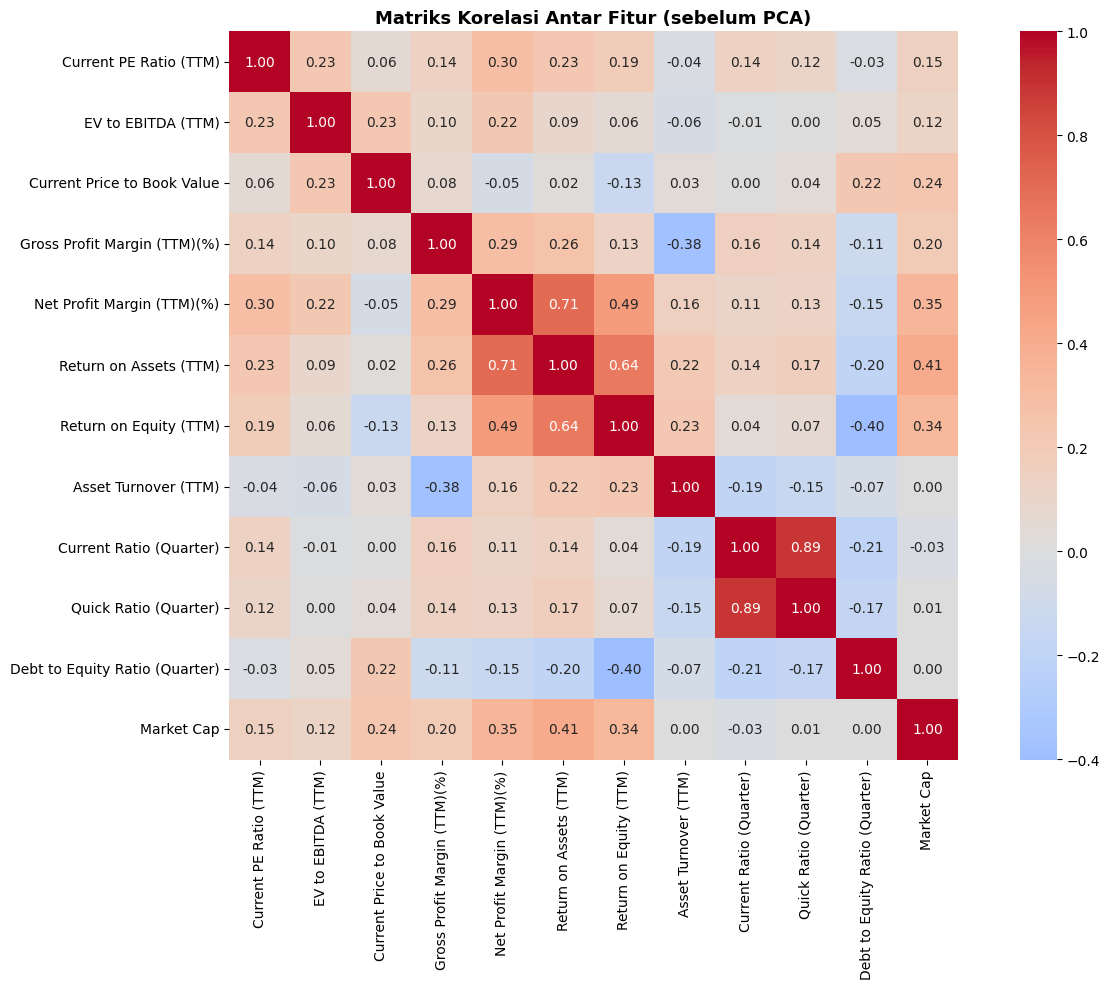

Pasangan fitur dengan |r| > 0.6:
                   Fitur 1                Fitur 2  Korelasi      Abs
   Current Ratio (Quarter)  Quick Ratio (Quarter)  0.891020 0.891020
Net Profit Margin (TTM)(%) Return on Assets (TTM)  0.708374 0.708374
    Return on Assets (TTM) Return on Equity (TTM)  0.644570 0.644570


In [ ]:
corr_matrix = pd.DataFrame(X_scaled, columns=features).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Matriks Korelasi Antar Fitur (sebelum PCA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tampilkan pasangan fitur dengan korelasi tinggi (|r| > 0.6)
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Fitur 1', 'Fitur 2', 'Korelasi']
corr_pairs['Abs'] = corr_pairs['Korelasi'].abs()
print("Pasangan fitur dengan |r| > 0.6:")
print(corr_pairs[corr_pairs['Abs'] > 0.6].sort_values('Abs', ascending=False).to_string(index=False))

In [ ]:
chi2, p = calculate_bartlett_sphericity(X_scaled)
print(f"Bartlett: chi2={chi2:.2f}, p={p:.4f} →", "Layak" if p < 0.05 else "Tidak layak")

kmo_all, kmo_model = calculate_kmo(X_scaled)
print(f"KMO Score: {kmo_model:.4f}")

Bartlett: chi2=3807.62, p=0.0000 → Layak
KMO Score: 0.6361


In [ ]:
import pandas as pd

# Print KMO per-variabel (MSA individual)
kmo_per_var = pd.Series(kmo_all, index=features).round(4).sort_values()

print("=== KMO per-Variabel (MSA Individual) ===\n")
print(kmo_per_var.to_string())
print(f"\nKMO Overall : {kmo_model:.4f}")
print("\n── Interpretasi Kaiser ──")
for var, val in kmo_per_var.items():
    if val < 0.5:
        ket = "❌ Unacceptable"
    elif val < 0.6:
        ket = "⚠️  Miserable"
    elif val < 0.7:
        ket = "〇 Mediocre"
    elif val < 0.8:
        ket = "✓  Middling"
    elif val < 0.9:
        ket = "✓✓ Meritorious"
    else:
        ket = "✓✓✓ Marvelous"
    print(f"  {var:<20} {val:.4f}  {ket}")

=== KMO per-Variabel (MSA Individual) ===

Current Price to Book Value       0.4067
Asset Turnover (TTM)              0.5047
Current Ratio (Quarter)           0.5371
Quick Ratio (Quarter)             0.5427
EV to EBITDA (TTM)                0.5552
Gross Profit Margin (TTM)(%)      0.6071
Debt to Equity Ratio (Quarter)    0.6422
Return on Assets (TTM)            0.7152
Net Profit Margin (TTM)(%)        0.7251
Return on Equity (TTM)            0.7264
Market Cap                        0.7633
Current PE Ratio (TTM)            0.8084

KMO Overall : 0.6361

── Interpretasi Kaiser ──
  Current Price to Book Value 0.4067  ❌ Unacceptable
  Asset Turnover (TTM) 0.5047  ⚠️  Miserable
  Current Ratio (Quarter) 0.5371  ⚠️  Miserable
  Quick Ratio (Quarter) 0.5427  ⚠️  Miserable
  EV to EBITDA (TTM)   0.5552  ⚠️  Miserable
  Gross Profit Margin (TTM)(%) 0.6071  〇 Mediocre
  Debt to Equity Ratio (Quarter) 0.6422  〇 Mediocre
  Return on Assets (TTM) 0.7152  ✓  Middling
  Net Profit Margin (TTM)(%) 0.7

## **Penentuan jumlah PC**

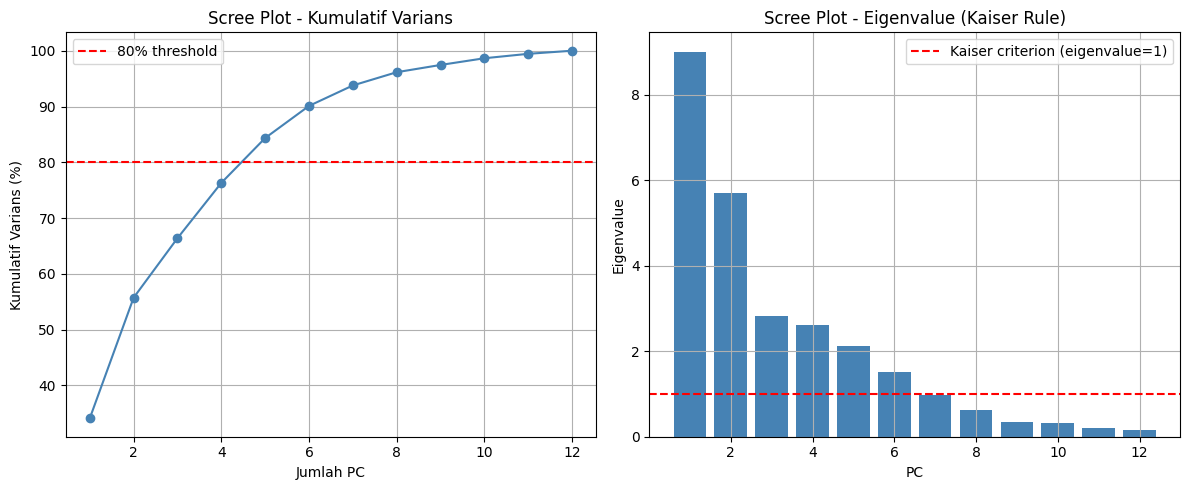

In [ ]:
pca_full = PCA()
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
eigenvalues = pca_full.explained_variance_

n_kaiser   = np.sum(eigenvalues > 1)
n_80pct    = np.argmax(cumvar >= 80) + 1
n_components = max(n_kaiser, n_80pct)

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# --- SCREE PLOT ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', color='steelblue')
plt.axhline(y=80, color='red', linestyle='--', label='80% threshold')
plt.xlabel('Jumlah PC')
plt.ylabel('Kumulatif Varians (%)')
plt.title('Scree Plot - Kumulatif Varians')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.bar(range(1, len(eigenvalues)+1), eigenvalues, color='steelblue')
plt.axhline(y=1, color='red', linestyle='--', label='Kaiser criterion (eigenvalue=1)')
plt.xlabel('PC')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot - Eigenvalue (Kaiser Rule)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

pca_full = PCA()
pca_full.fit(X_scaled)

ev = pca_full.explained_variance_ratio_ * 100
eigenvalues = pca_full.explained_variance_
cumvar = np.cumsum(ev)

df_var = pd.DataFrame({
    'PC'             : [f'PC{i+1}' for i in range(len(ev))],
    'Eigenvalue'     : eigenvalues.round(4),
    'Varians (%)'    : ev.round(2),
    'Kumulatif (%)'  : cumvar.round(2),
    'Kaiser (>1)'    : ['✓' if e > 1 else '✗' for e in eigenvalues]
})

n_kaiser  = int(np.sum(eigenvalues > 1))
n_80pct   = int(np.argmax(cumvar >= 80) + 1)
n_components = max(n_kaiser, n_80pct)

print(df_var.to_string(index=False))
print(f"\nKriterion Kaiser (eigenvalue > 1) : {n_kaiser} komponen")
print(f"Kumulatif varians ≥ 80%           : {n_80pct} komponen")
print(f"n_components dipilih (max keduanya): {n_components}")

  PC  Eigenvalue  Varians (%)  Kumulatif (%) Kaiser (>1)
 PC1      9.0159        34.11          34.11           ✓
 PC2      5.7158        21.62          55.73           ✓
 PC3      2.8195        10.67          66.40           ✓
 PC4      2.6203         9.91          76.31           ✓
 PC5      2.1247         8.04          84.35           ✓
 PC6      1.5220         5.76          90.11           ✓
 PC7      0.9693         3.67          93.78           ✗
 PC8      0.6272         2.37          96.15           ✗
 PC9      0.3438         1.30          97.45           ✗
PC10      0.3176         1.20          98.65           ✗
PC11      0.2097         0.79          99.44           ✗
PC12      0.1470         0.56         100.00           ✗

Kriterion Kaiser (eigenvalue > 1) : 6 komponen
Kumulatif varians ≥ 80%           : 5 komponen
n_components dipilih (max keduanya): 6


In [ ]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

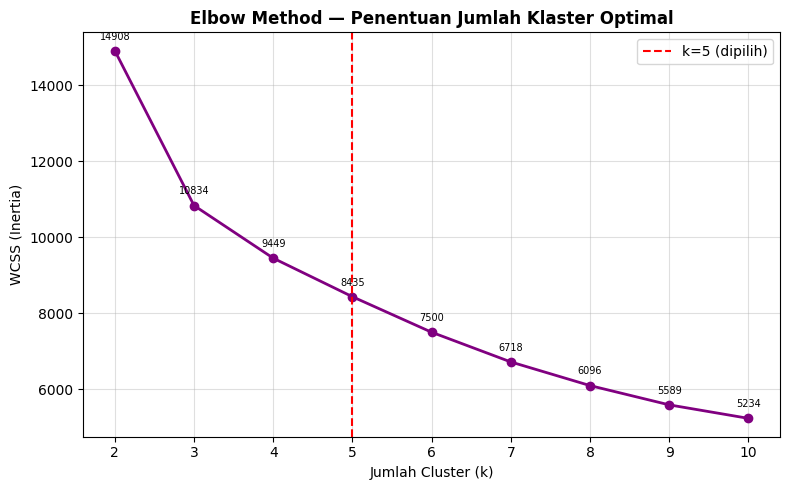

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', color='purple', linewidth=2)
plt.axvline(x=5, color='red', linestyle='--', label='k=5 (dipilih)')
plt.title('Elbow Method — Penentuan Jumlah Klaster Optimal', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS (Inertia)')
plt.legend()
plt.grid(True, alpha=0.4)
for k, w in zip(K_range, wcss):
    plt.annotate(f'{w:.0f}', (k, w), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=7)
plt.tight_layout()
plt.show()

Loading Matrix PCA:
                                  PC1    PC2    PC3    PC4    PC5
Current PE Ratio (TTM)          0.274  0.196  0.558  0.624 -0.427
EV to EBITDA (TTM)              0.842 -0.474 -0.056 -0.217 -0.071
Current Price to Book Value     0.095 -0.159  0.094  0.181  0.410
Gross Profit Margin (TTM)(%)    0.049  0.061  0.033 -0.008  0.059
Net Profit Margin (TTM)(%)      0.394  0.604 -0.289  0.121  0.339
Return on Assets (TTM)          0.146  0.309 -0.108  0.007  0.124
Return on Equity (TTM)          0.142  0.364 -0.165 -0.135 -0.218
Asset Turnover (TTM)            0.003  0.056 -0.130  0.024 -0.027
Current Ratio (Quarter)         0.034  0.129  0.511 -0.302  0.270
Quick Ratio (Quarter)           0.041  0.138  0.516 -0.315  0.332
Debt to Equity Ratio (Quarter) -0.028 -0.264 -0.073  0.551  0.522
Market Cap                      0.066  0.078 -0.055  0.061  0.084


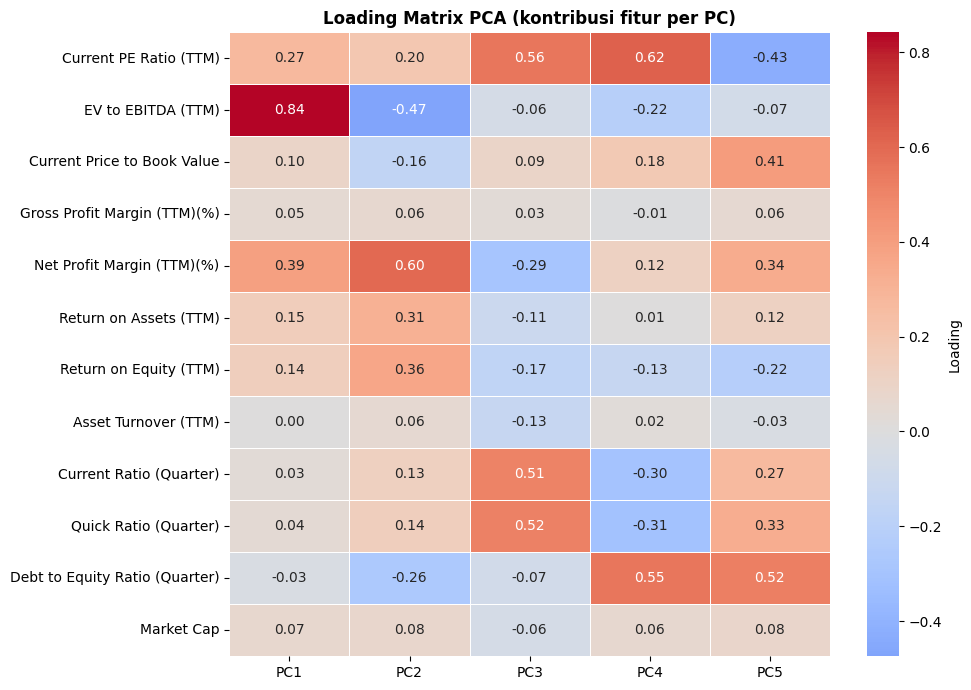


Fitur dominan per PC (|loading| tertinggi):
  PC1: EV to EBITDA (TTM), Net Profit Margin (TTM)(%), Current PE Ratio (TTM)
  PC2: Net Profit Margin (TTM)(%), EV to EBITDA (TTM), Return on Equity (TTM)
  PC3: Current PE Ratio (TTM), Quick Ratio (Quarter), Current Ratio (Quarter)
  PC4: Current PE Ratio (TTM), Debt to Equity Ratio (Quarter), Quick Ratio (Quarter)
  PC5: Debt to Equity Ratio (Quarter), Current PE Ratio (TTM), Current Price to Book Value


In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print("Loading Matrix PCA:")
print(loadings.round(3).to_string())

# Heatmap loading matrix
plt.figure(figsize=(10, 7))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'label': 'Loading'})
plt.title('Loading Matrix PCA (kontribusi fitur per PC)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Fitur dominan per PC
print("\nFitur dominan per PC (|loading| tertinggi):")
for pc in loadings.columns:
    top = loadings[pc].abs().nlargest(3).index.tolist()
    print(f"  {pc}: {', '.join(top)}")

## **Penentuan Jumlah Klaster**

 k  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
 2        0.4090            1.2246               295.98
 3        0.4552            1.0818               370.54
 4        0.3269            1.2895               326.33
 5        0.3369            1.1417               300.53
 6        0.3416            1.1665               292.15
 7        0.3557            1.1127               288.66
 8        0.3341            1.1217               285.23
 9        0.3386            1.1204               281.96
10        0.3486            1.0821               273.99

Catatan: ↑ = semakin tinggi semakin baik, ↓ = semakin rendah semakin baik


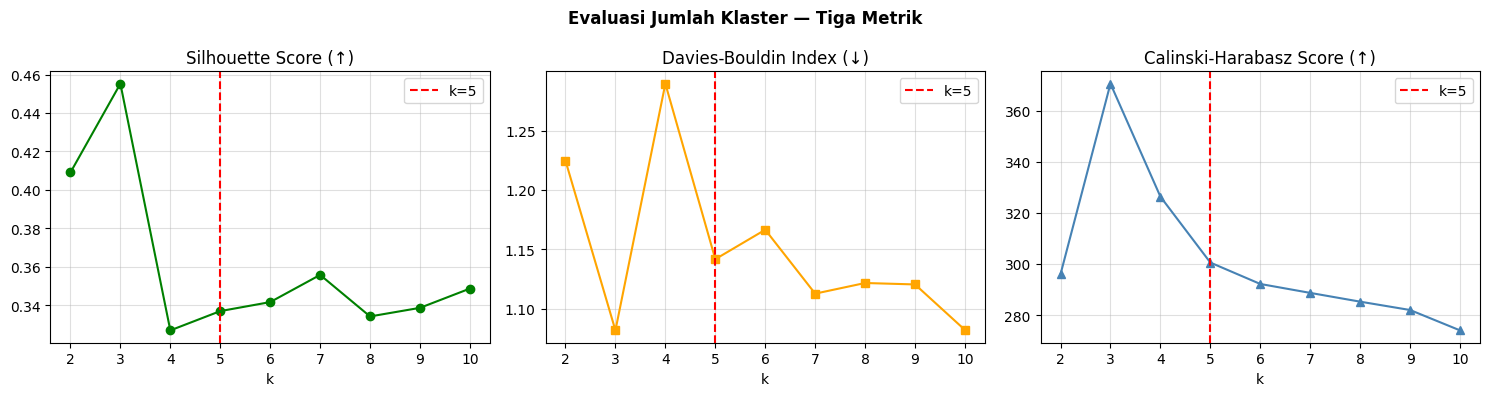

In [ ]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

db_scores  = []
ch_scores  = []
sil_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    db_scores.append(davies_bouldin_score(X_pca, labels))
    ch_scores.append(calinski_harabasz_score(X_pca, labels))
    sil_scores.append(silhouette_score(X_pca, labels))

df_eval = pd.DataFrame({
    'k'                        : list(range(2, 11)),
    'Silhouette ↑'             : [round(s, 4) for s in sil_scores],
    'Davies-Bouldin ↓'         : [round(d, 4) for d in db_scores],
    'Calinski-Harabasz ↑'      : [round(c, 2) for c in ch_scores]
})
print(df_eval.to_string(index=False))
print("\nCatatan: ↑ = semakin tinggi semakin baik, ↓ = semakin rendah semakin baik")

# Plot ketiga metrik
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
K = list(range(2, 11))

axes[0].plot(K, sil_scores, marker='o', color='green')
axes[0].axvline(x=5, color='red', linestyle='--', label='k=5')
axes[0].set_title('Silhouette Score (↑)')
axes[0].set_xlabel('k'); axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(K, db_scores, marker='s', color='orange')
axes[1].axvline(x=5, color='red', linestyle='--', label='k=5')
axes[1].set_title('Davies-Bouldin Index (↓)')
axes[1].set_xlabel('k'); axes[1].legend(); axes[1].grid(True, alpha=0.4)

axes[2].plot(K, ch_scores, marker='^', color='steelblue')
axes[2].axvline(x=5, color='red', linestyle='--', label='k=5')
axes[2].set_title('Calinski-Harabasz Score (↑)')
axes[2].set_xlabel('k'); axes[2].legend(); axes[2].grid(True, alpha=0.4)

plt.suptitle('Evaluasi Jumlah Klaster — Tiga Metrik', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
k_final = 5
km_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
ihsg_clean['Cluster'] = km_final.fit_predict(X_pca)

print(ihsg_clean['Cluster'].value_counts().sort_index())
print("\nRata-rata per klaster:")
print(ihsg_clean.groupby('Cluster')[features + ['Market Cap']].mean().round(2).T)

Cluster
0    128
1    546
2    114
3     50
4     54
Name: count, dtype: int64

Rata-rata per klaster:
Cluster                             0      1      2      3      4
Current PE Ratio (TTM)         -13.23  12.99  21.19  99.14 -32.89
EV to EBITDA (TTM)             -25.47   7.71   6.28  76.83  88.86
Current Price to Book Value      2.13   1.26   1.43   4.02   3.22
Gross Profit Margin (TTM)(%)     0.20   0.30   0.38   0.41   0.24
Net Profit Margin (TTM)(%)      -0.63   0.07   0.14   0.10  -0.21
Return on Assets (TTM)          -0.11   0.03   0.05   0.02  -0.05
Return on Equity (TTM)          -0.19   0.07   0.07   0.05  -0.10
Asset Turnover (TTM)             0.36   0.80   0.51   0.36   0.52
Current Ratio (Quarter)          2.60   2.04   8.78   5.14   2.15
Quick Ratio (Quarter)            1.60   1.30   6.29   3.13   1.50
Debt to Equity Ratio (Quarter)   0.94   0.57   0.26   0.47   1.06
Market Cap                       5.70   7.14   7.00   7.62   6.42
Market Cap                       5.70  

In [ ]:
k_final = 5
km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
ihsg_clean['Cluster'] = km_final.fit_predict(X_pca)

# Rename klaster agar lebih mudah dibaca
label_map = {
    0: '0-Distress Ringan',
    1: '1-Value/Mature',
    2: '2-Growth Likuid',
    3: '3-Spekulatif Premium',
    4: '4-Distress Berat'
}

print("Distribusi klaster:")
print(ihsg_clean['Cluster'].value_counts().sort_index())

print("\nRata-rata per klaster:")
profil = ihsg_clean.groupby('Cluster')[features].mean().round(2)
profil.index = [label_map[i] for i in profil.index]
print(profil.T.to_string())

Distribusi klaster:
Cluster
0    128
1    546
2    114
3     50
4     54
Name: count, dtype: int64

Rata-rata per klaster:
                                0-Distress Ringan  1-Value/Mature  2-Growth Likuid  3-Spekulatif Premium  4-Distress Berat
Current PE Ratio (TTM)                     -13.23           12.99            21.19                 99.14            -32.89
EV to EBITDA (TTM)                         -25.47            7.71             6.28                 76.83             88.86
Current Price to Book Value                  2.13            1.26             1.43                  4.02              3.22
Gross Profit Margin (TTM)(%)                 0.20            0.30             0.38                  0.41              0.24
Net Profit Margin (TTM)(%)                  -0.63            0.07             0.14                  0.10             -0.21
Return on Assets (TTM)                      -0.11            0.03             0.05                  0.02             -0.05
Return on Equity

In [ ]:
# Profil rata-rata tiap klaster
profil = ihsg_clean.groupby('Cluster')[features].mean().round(2)
print(profil.T.to_string())

Cluster                             0      1      2      3      4
Current PE Ratio (TTM)         -13.23  12.99  21.19  99.14 -32.89
EV to EBITDA (TTM)             -25.47   7.71   6.28  76.83  88.86
Current Price to Book Value      2.13   1.26   1.43   4.02   3.22
Gross Profit Margin (TTM)(%)     0.20   0.30   0.38   0.41   0.24
Net Profit Margin (TTM)(%)      -0.63   0.07   0.14   0.10  -0.21
Return on Assets (TTM)          -0.11   0.03   0.05   0.02  -0.05
Return on Equity (TTM)          -0.19   0.07   0.07   0.05  -0.10
Asset Turnover (TTM)             0.36   0.80   0.51   0.36   0.52
Current Ratio (Quarter)          2.60   2.04   8.78   5.14   2.15
Quick Ratio (Quarter)            1.60   1.30   6.29   3.13   1.50
Debt to Equity Ratio (Quarter)   0.94   0.57   0.26   0.47   1.06
Market Cap                       5.70   7.14   7.00   7.62   6.42


In [ ]:
# Lihat sample saham per klaster
for c in sorted(ihsg_clean['Cluster'].unique()):
    print(f"\n=== Klaster {c} ({(ihsg_clean['Cluster']==c).sum()} saham) ===")
    print(ihsg_clean[ihsg_clean['Cluster']==c]['Symbol'].values)


=== Klaster 0 (128 saham) ===
['SBAT' 'DEAL' 'TOYS' 'SIMA' 'INDX' 'HADE' 'TOPS' 'LMAS' 'ALTO' 'RICY'
 'BELI' 'BINA' 'TRIO' 'WIKA' 'POLU' 'ANJT' 'LINK' 'TFCO' 'AGRO' 'SRIL'
 'SFAN' 'TOBA' 'OMRE' 'NETV' 'CENT' 'IIKP' 'DOID' 'FMII' 'OASA' 'TDPM'
 'SUGI' 'ADHI' 'ADCP' 'HOME' 'PTPP' 'ASLI' 'FORU' 'PPRO' 'MABA' 'ZINC'
 'SOSS' 'PPRE' 'SQMI' 'WSBP' 'RODA' 'WMPP' 'BIKE' 'STRK' 'MDLN' 'SMRU'
 'TAMU' 'COCO' 'SOTS' 'PBRX' 'HOKI' 'WEGE' 'SULI' 'True' 'MAGP' 'GTBO'
 'KBRI' 'NZIA' 'POSA' 'BTEK' 'INAF' 'FITT' 'MTFN' 'DART' 'ETWA' 'TARA'
 'IKPM' 'ALMI' 'ASHA' 'KOKA' 'AKKU' 'IKAI' 'GPSO' 'BEBS' 'KBAG' 'ASPI'
 'BAJA' 'KREN' 'TRON' 'HILL' 'MTRA' 'BINO' 'SAGE' 'GAMA' 'PSDN' 'MANG'
 'MTPS' 'PTMP' 'HKMU' 'BAPA' 'ANDI' 'PMMP' 'ABBA' 'ZBRA' 'TAXI' 'LMPI'
 'CPRI' 'CTTH' 'MARI' 'FINN' 'JSKY' 'MEDS' 'BAUT' 'CANI' 'CBMF' 'ENVY'
 'BAPI' 'KRYA' 'AYLS' 'OPMS' 'NASI' 'PGLI' 'HDIT' 'MPOW' 'TGRA' 'POLY'
 'AIMS' 'BOSS' 'DEFI' 'LRNA' 'TAYS' 'BIMA' 'SWAT' 'OCAP']

=== Klaster 1 (546 saham) ===
['KAYU' 'UNIT' 'LMSH' 'CNTX'

In [ ]:
from sklearn.cluster import AgglomerativeClustering

results = []

for k in [4, 5, 6]:
    # KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl_km = km.fit_predict(X_pca)

    # Agglomerative
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    lbl_agg = agg.fit_predict(X_pca)

    for method, lbl in [('KMeans', lbl_km), ('Agglomerative', lbl_agg)]:
        results.append({
            'Metode'            : method,
            'k'                 : k,
            'Silhouette'        : round(silhouette_score(X_pca, lbl), 4),
            'Davies-Bouldin'    : round(davies_bouldin_score(X_pca, lbl), 4),
            'Calinski-Harabasz' : round(calinski_harabasz_score(X_pca, lbl), 2)
        })

df_comp = pd.DataFrame(results)
print(df_comp.to_string(index=False))

       Metode  k  Silhouette  Davies-Bouldin  Calinski-Harabasz
       KMeans  4      0.3269          1.2895             326.33
Agglomerative  4      0.3180          1.3853             270.36
       KMeans  5      0.3369          1.1417             300.53
Agglomerative  5      0.3282          1.3846             256.22
       KMeans  6      0.3416          1.1665             292.15
Agglomerative  6      0.3382          1.2716             245.04


**DBSCAN**

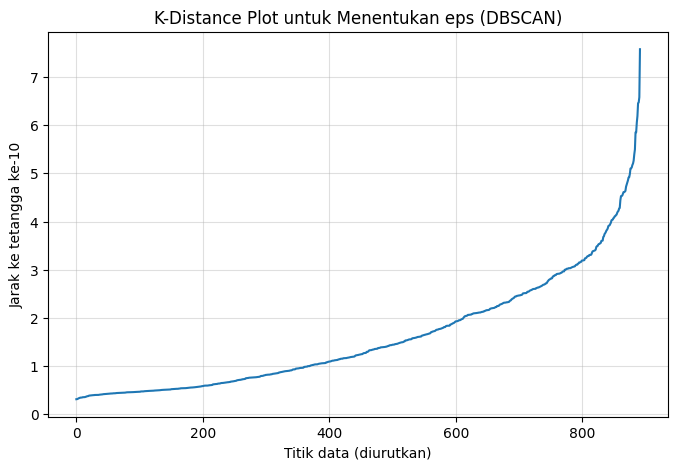

min_samples yang digunakan: 10
Rentang k-distance: 0.3076 - 7.5795
Beberapa percentile: 75%=2.2545, 90%=3.1939, 95%=4.0291


In [ ]:
# DBSCAN — tentukan eps via k-distance plot dulu
from sklearn.neighbors import NearestNeighbors

min_samples = 2 * X_pca.shape[1]  # rule of thumb: 2 x jumlah dimensi (2*5=10)
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

# Urutkan jarak ke-k tetangga terjauh, cari titik 'siku'
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel('Titik data (diurutkan)')
plt.ylabel(f'Jarak ke tetangga ke-{min_samples}')
plt.title('K-Distance Plot untuk Menentukan eps (DBSCAN)')
plt.grid(True, alpha=0.4)
plt.show()

print(f"min_samples yang digunakan: {min_samples}")
print(f"Rentang k-distance: {k_distances.min():.4f} - {k_distances.max():.4f}")
print(f"Beberapa percentile: 75%={np.percentile(k_distances,75):.4f}, 90%={np.percentile(k_distances,90):.4f}, 95%={np.percentile(k_distances,95):.4f}")

In [ ]:
# ============================================================
# DBSCAN — evaluasi FAIR (Opsi A): noise diremap sebagai klaster tersendiri
# Semua 892 saham tetap dihitung dalam metrik, tidak ada yang dibuang
# ============================================================
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd

eps_candidates = [2.0, 2.25, 2.5, 2.75, 3.0, 3.2]
min_samples = 10

dbscan_results = []
for eps in eps_candidates:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels_db = db.fit_predict(X_pca)

    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = list(labels_db).count(-1)

    # ✅ Remap noise dari -1 ke ID klaster baru
    labels_eval = labels_db.copy()
    labels_eval[labels_eval == -1] = n_clusters  # noise → klaster ke-(n+1)

    n_unique = len(set(labels_eval))
    if n_unique >= 2:
        sil = silhouette_score(X_pca, labels_eval)
        dbi = davies_bouldin_score(X_pca, labels_eval)
        ch  = calinski_harabasz_score(X_pca, labels_eval)
    else:
        sil, dbi, ch = np.nan, np.nan, np.nan

    dbscan_results.append({
        'eps'              : eps,
        'min_samples'      : min_samples,
        'n_clusters'       : n_clusters,
        'n_noise'          : n_noise,
        'noise_pct'        : round(n_noise / len(labels_db) * 100, 2),
        'Silhouette'       : round(sil, 4) if not np.isnan(sil) else np.nan,
        'Davies-Bouldin'   : round(dbi, 4) if not np.isnan(dbi) else np.nan,
        'Calinski-Harabasz': round(ch,  2)  if not np.isnan(ch)  else np.nan,
    })

df_dbscan = pd.DataFrame(dbscan_results)
print("=== DBSCAN Fair Evaluation (Opsi A) ===\n")
print(df_dbscan.round(4).to_string(index=False))

print("\n── Konfigurasi terbaik (Silhouette tertinggi) ──")
best = df_dbscan.dropna(subset=['Silhouette']).sort_values('Silhouette', ascending=False).iloc[0]
print(best.to_string())

=== DBSCAN Fair Evaluation (Opsi A) ===

 eps  min_samples  n_clusters  n_noise  noise_pct  Silhouette  Davies-Bouldin  Calinski-Harabasz
2.00           10           3      213      23.88      0.3334          2.0661              63.25
2.25           10           5      130      14.57      0.3697          1.7362              71.50
2.50           10           3       94      10.54      0.4223          1.9897              77.17
2.75           10           3       69       7.74      0.4399          1.9414              87.23
3.00           10           2       47       5.27      0.4377          2.5352              70.65
3.20           10           1       30       3.36      0.4726          2.6152              29.94

── Konfigurasi terbaik (Silhouette tertinggi) ──
eps                   3.2000
min_samples          10.0000
n_clusters            1.0000
n_noise              30.0000
noise_pct             3.3600
Silhouette            0.4726
Davies-Bouldin        2.6152
Calinski-Harabasz    29.940

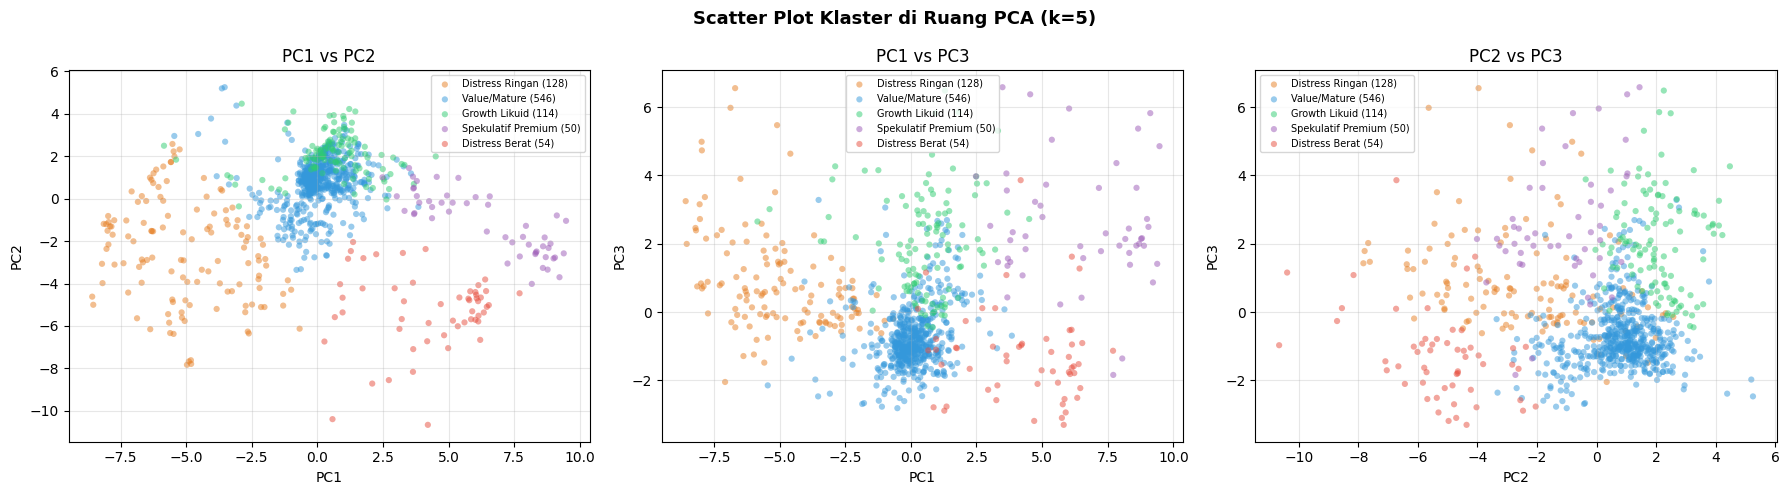

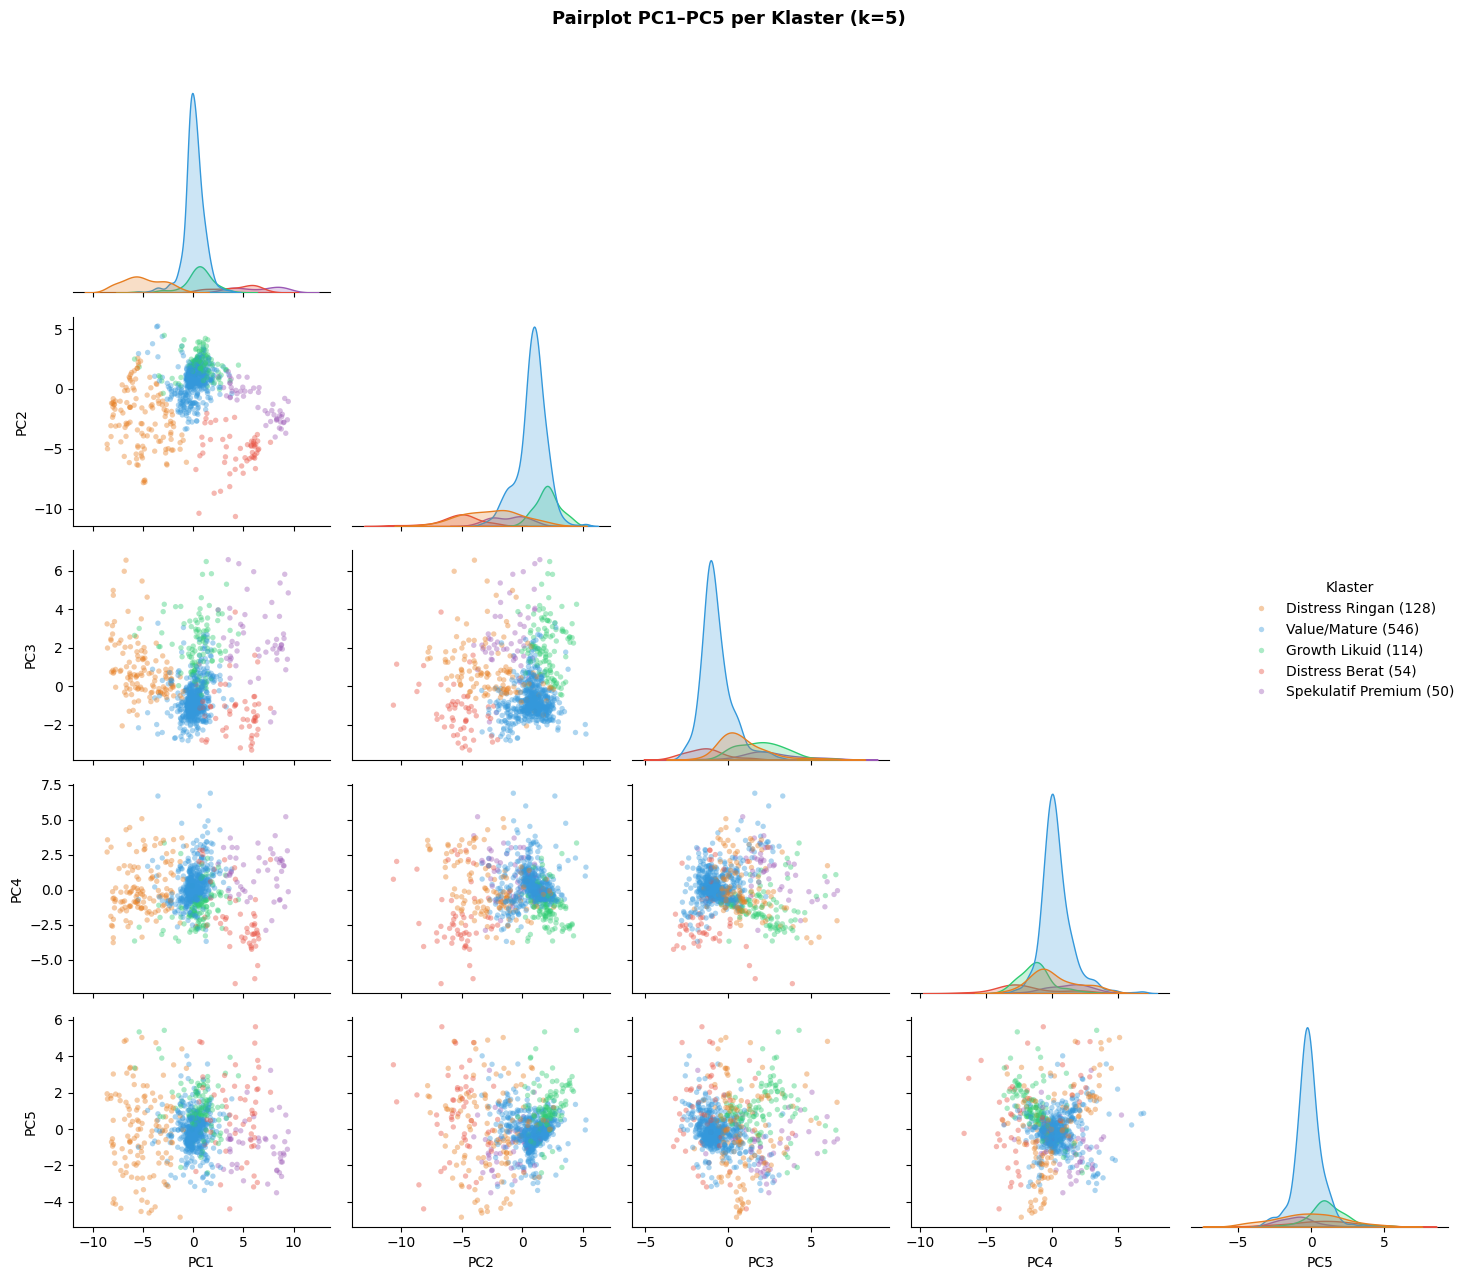

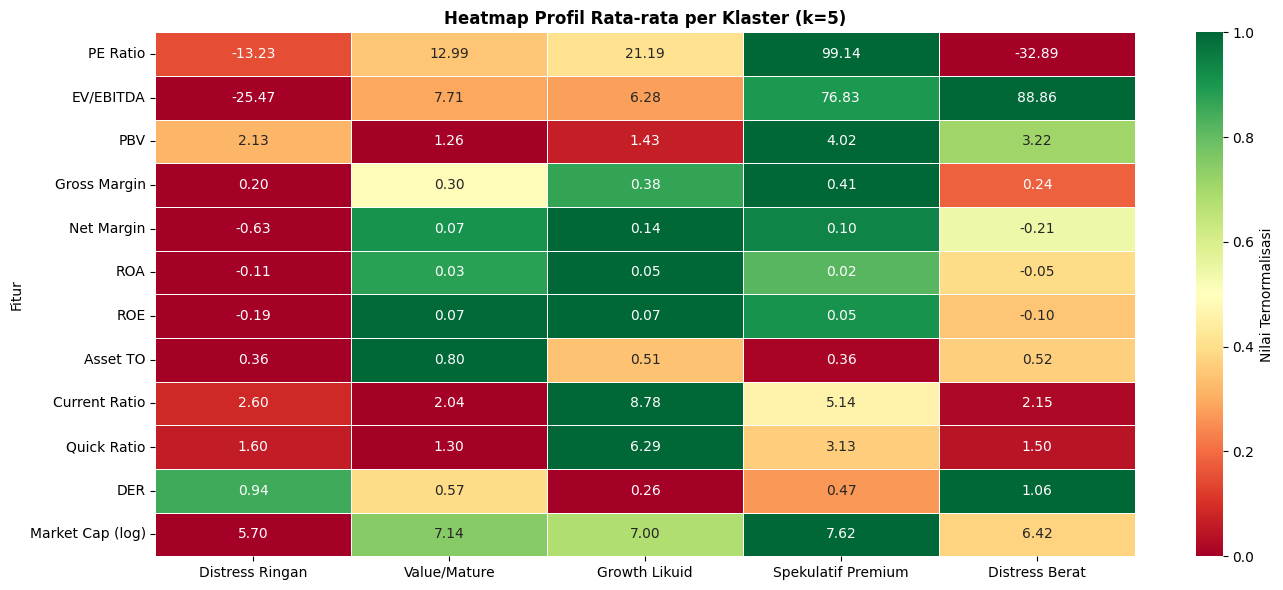

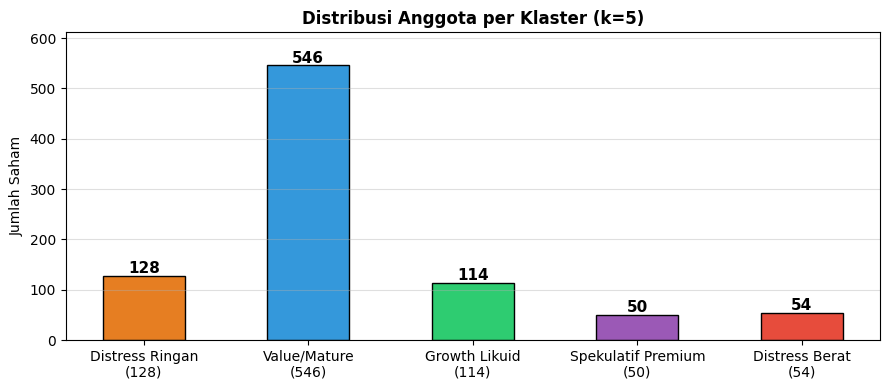

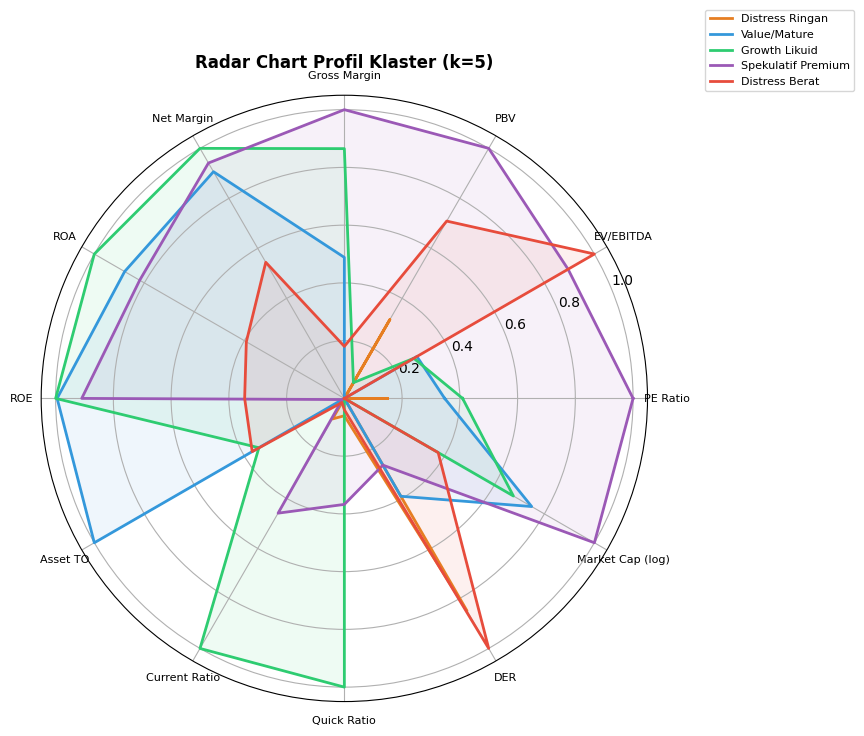

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

warna = {
    0: '#e67e22',  # Distress Ringan - oranye
    1: '#3498db',  # Value/Mature - biru
    2: '#2ecc71',  # Growth Likuid - hijau
    3: '#9b59b6',  # Spekulatif Premium - ungu
    4: '#e74c3c'   # Distress Berat - merah
}

label_klaster = {
    0: 'Distress Ringan (128)',
    1: 'Value/Mature (546)',
    2: 'Growth Likuid (114)',
    3: 'Spekulatif Premium (50)',
    4: 'Distress Berat (54)'
}

# ============================================================
# PLOT 1: Scatter PC1-PC2, PC1-PC3, PC2-PC3
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pasangan = [(0,1), (0,2), (1,2)]

for ax, (i,j) in zip(axes, pasangan):
    for c in sorted(ihsg_clean['Cluster'].unique()):
        mask = ihsg_clean['Cluster'] == c
        ax.scatter(
            X_pca[mask, i], X_pca[mask, j],
            c=warna[c], label=label_klaster[c],
            alpha=0.5, s=20, edgecolors='none'
        )
    ax.set_xlabel(f'PC{i+1}'); ax.set_ylabel(f'PC{j+1}')
    ax.set_title(f'PC{i+1} vs PC{j+1}')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Scatter Plot Klaster di Ruang PCA (k=5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2: Pairplot PC1-PC5
# ============================================================
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(5)])
df_pca['Klaster'] = ihsg_clean['Cluster'].map(label_klaster)

warna_palette = {v: warna[k] for k, v in label_klaster.items()}

g = sns.pairplot(
    df_pca,
    hue='Klaster',
    palette=warna_palette,
    vars=[f'PC{i+1}' for i in range(5)],
    plot_kws={'alpha': 0.4, 's': 15, 'edgecolor': 'none'},
    diag_kind='kde',
    corner=True
)
g.fig.suptitle('Pairplot PC1–PC5 per Klaster (k=5)', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 3: Heatmap profil klaster
# ============================================================
profil = ihsg_clean.groupby('Cluster')[features].mean()
profil.index = [label_klaster[i].split(' (')[0] for i in profil.index]
profil.columns = [
    'PE Ratio', 'EV/EBITDA', 'PBV',
    'Gross Margin', 'Net Margin',
    'ROA', 'ROE', 'Asset TO',
    'Current Ratio', 'Quick Ratio',
    'DER', 'Market Cap (log)'
]

profil_norm = (profil - profil.min()) / (profil.max() - profil.min())

plt.figure(figsize=(14, 6))
sns.heatmap(
    profil_norm.T,
    annot=profil.T.round(2),
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Nilai Ternormalisasi'}
)
plt.title('Heatmap Profil Rata-rata per Klaster (k=5)', fontsize=12, fontweight='bold')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 4: Bar distribusi
# ============================================================
plt.figure(figsize=(9, 4))
dist = ihsg_clean['Cluster'].value_counts().sort_index()
label_bar = [label_klaster[i].replace(' (', '\n(') for i in range(5)]
bars = plt.bar(
    label_bar, dist.values,
    color=[warna[i] for i in range(5)],
    edgecolor='black', width=0.5
)
for bar, val in zip(bars, dist.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontsize=11, fontweight='bold')
plt.title('Distribusi Anggota per Klaster (k=5)', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Saham')
plt.ylim(0, max(dist.values) * 1.12)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 5: Radar chart
# ============================================================
kategori = list(profil.columns)
N = len(kategori)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for idx, nama in enumerate(profil.index):
    values = profil_norm.loc[nama].tolist() + profil_norm.loc[nama].tolist()[:1]
    ax.plot(angles, values, linewidth=2, label=nama, color=list(warna.values())[idx])
    ax.fill(angles, values, alpha=0.08, color=list(warna.values())[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(kategori, fontsize=8)
ax.set_title('Radar Chart Profil Klaster (k=5)', fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)
plt.tight_layout()
plt.show()

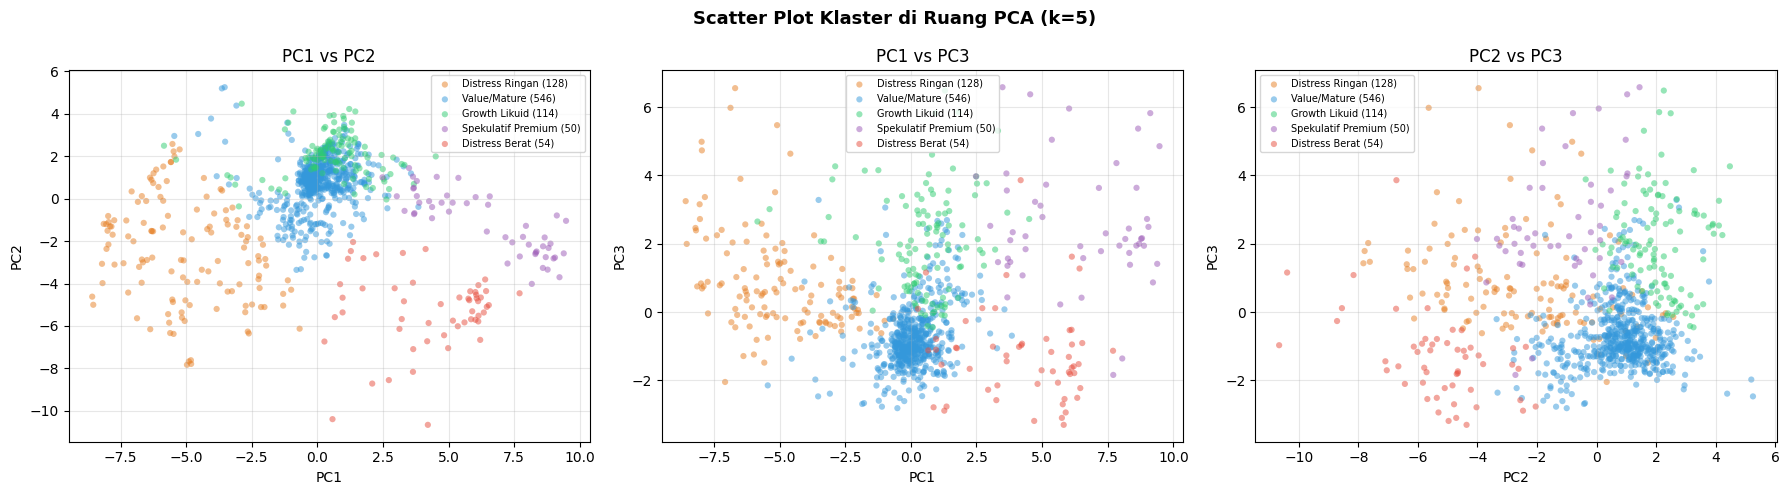

In [ ]:
# ============================================================
# PLOT 1: Scatter PC1-PC2, PC1-PC3, PC2-PC3
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pasangan = [(0,1), (0,2), (1,2)]

for ax, (i,j) in zip(axes, pasangan):
    for c in sorted(ihsg_clean['Cluster'].unique()):
        mask = ihsg_clean['Cluster'] == c
        ax.scatter(
            X_pca[mask, i], X_pca[mask, j],
            c=warna[c], label=label_klaster[c],
            alpha=0.5, s=20, edgecolors='none'
        )
    ax.set_xlabel(f'PC{i+1}'); ax.set_ylabel(f'PC{j+1}')
    ax.set_title(f'PC{i+1} vs PC{j+1}')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Scatter Plot Klaster di Ruang PCA (k=5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

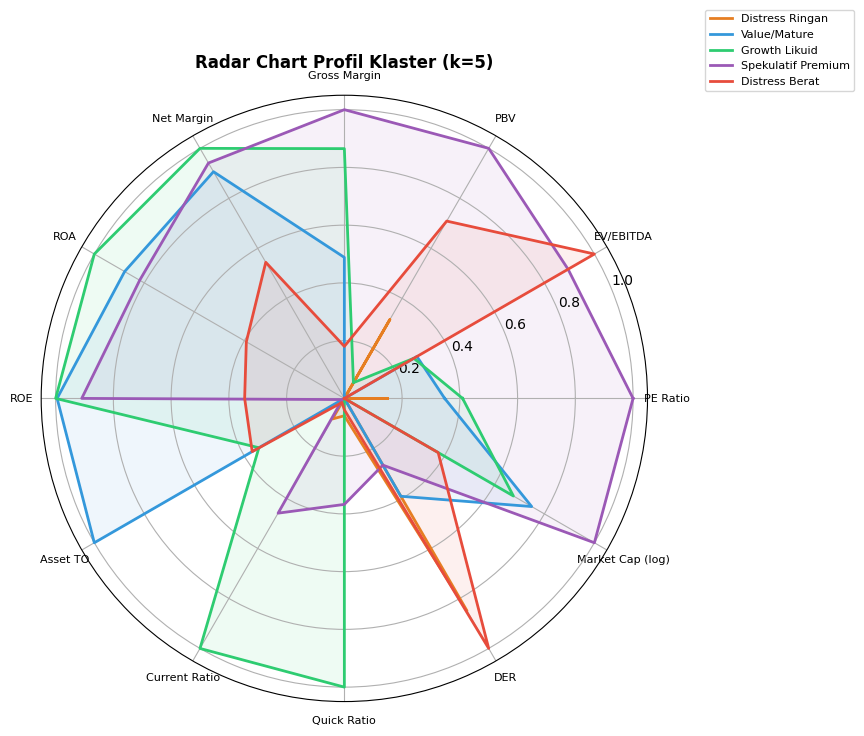

In [ ]:
# ============================================================
# PLOT 5: Radar chart
# ============================================================
kategori = list(profil.columns)
N = len(kategori)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for idx, nama in enumerate(profil.index):
    values = profil_norm.loc[nama].tolist() + profil_norm.loc[nama].tolist()[:1]
    ax.plot(angles, values, linewidth=2, label=nama, color=list(warna.values())[idx])
    ax.fill(angles, values, alpha=0.08, color=list(warna.values())[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(kategori, fontsize=8)
ax.set_title('Radar Chart Profil Klaster (k=5)', fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


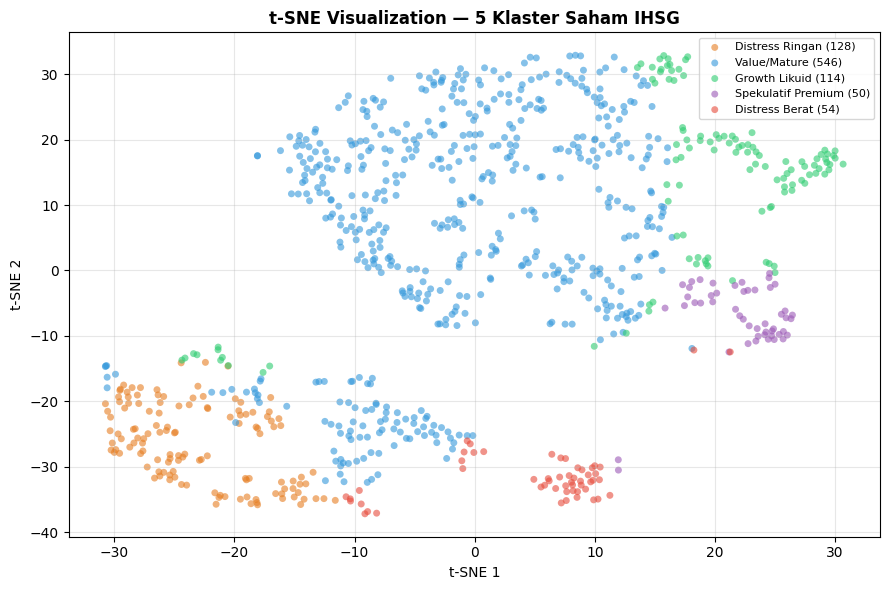

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca)

plt.figure(figsize=(9, 6))
for c in sorted(ihsg_clean['Cluster'].unique()):
    mask = ihsg_clean['Cluster'] == c
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=warna[c], label=label_klaster[c],
                alpha=0.6, s=25, edgecolors='none')

plt.title('t-SNE Visualization — 5 Klaster Saham IHSG', fontsize=12, fontweight='bold')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.legend(fontsize=8, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()